# Final Results Visualization
This notebook reads experiment outputs and generates paper-ready figures.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

FIGURE_DPI = 600
SAVE_PDF = True
SAVE_TIFF = True
PIPELINE_COLOR = {'A': '#1f77b4', 'B': '#d55e00'}

plt.rcParams.update(
    {
        'savefig.bbox': 'tight',
        'savefig.facecolor': 'white',
        'savefig.edgecolor': 'white',
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'font.size': 10,
        'axes.titlesize': 11,
        'axes.labelsize': 10,
        'legend.fontsize': 9,
        'lines.linewidth': 2.0,
    }
)

results_path = Path('../reports/tables/final_results.csv')
agg_path = Path('../reports/tables/aggregated_results.csv')
fig_dir = Path('../reports/figures')
fig_dir.mkdir(parents=True, exist_ok=True)

if not results_path.exists():
    raise FileNotFoundError(f'Missing final results: {results_path}')

results_df = pd.read_csv(results_path)
if agg_path.exists():
    agg_df = pd.read_csv(agg_path)
else:
    agg_df = pd.DataFrame()

print(f'final_results rows: {len(results_df)}')
print(f'aggregated rows: {len(agg_df)}')

final_results rows: 4800
aggregated rows: 120


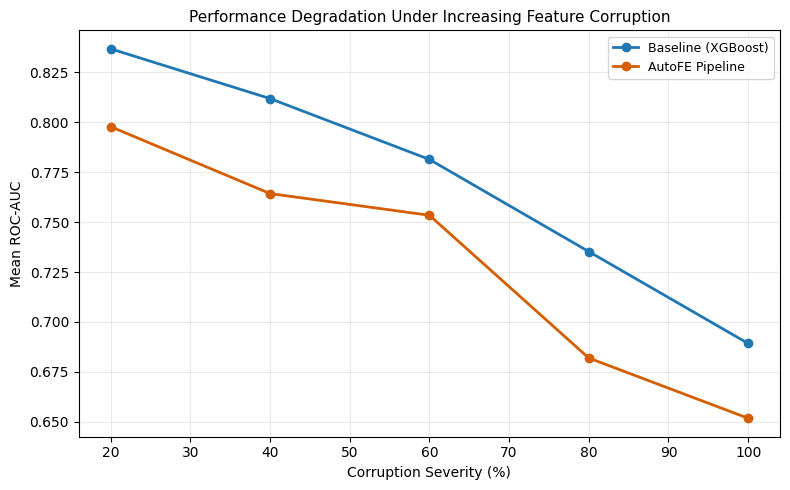

Saved: ..\reports\figures\degradation_curve.png
Saved: ..\reports\figures\degradation_curve.tiff
Saved: ..\reports\figures\degradation_curve.pdf


In [2]:
# Degradation curve: mean ROC-AUC vs severity for baseline vs AutoFE.
pipeline_name = {'A': 'Baseline (XGBoost)', 'B': 'AutoFE Pipeline'}
curve_df = (
    results_df.groupby(['severity', 'pipeline'], as_index=False)
    .agg(mean_roc_auc=('roc_auc', 'mean'))
    .sort_values(by=['pipeline', 'severity'])
)

plt.figure(figsize=(8, 5))
for pipeline, group in curve_df.groupby('pipeline'):
    plt.plot(
        group['severity'] * 100,
        group['mean_roc_auc'],
        marker='o',
        color=PIPELINE_COLOR.get(str(pipeline), '#2f2f2f'),
        label=pipeline_name.get(str(pipeline), str(pipeline)),
    )

plt.xlabel('Corruption Severity (%)')
plt.ylabel('Mean ROC-AUC')
plt.title('Performance Degradation Under Increasing Feature Corruption')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
degradation_png_path = fig_dir / 'degradation_curve.png'
plt.savefig(degradation_png_path, dpi=FIGURE_DPI, format='png')
if SAVE_TIFF:
    degradation_tiff_path = fig_dir / 'degradation_curve.tiff'
    plt.savefig(degradation_tiff_path, dpi=FIGURE_DPI, format='tiff')
if SAVE_PDF:
    degradation_pdf_path = fig_dir / 'degradation_curve.pdf'
    plt.savefig(degradation_pdf_path, format='pdf')
plt.show()
print(f'Saved: {degradation_png_path}')
if SAVE_TIFF:
    print(f'Saved: {degradation_tiff_path}')
if SAVE_PDF:
    print(f'Saved: {degradation_pdf_path}')

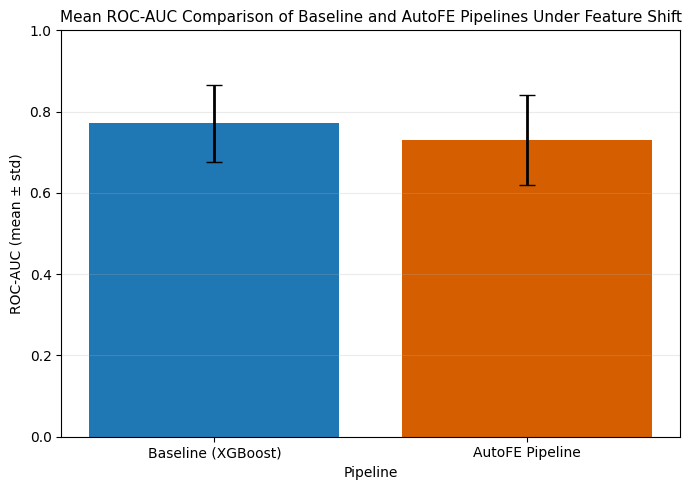

Saved: ..\reports\figures\average_performance.png
Saved: ..\reports\figures\average_performance.tiff
Saved: ..\reports\figures\average_performance.pdf
Saved: ..\reports\figures\figure_captions.md


,pipeline,mean_roc_auc,std_roc_auc,pipeline_label
0,A,0.770930,0.094780,Baseline (XGBoost)
1,B,0.729861,0.111637,AutoFE Pipeline


In [3]:
# Average performance plot per pipeline across all datasets/seeds/shifts.
avg_df = (
    results_df.groupby('pipeline', as_index=False)
    .agg(mean_roc_auc=('roc_auc', 'mean'), std_roc_auc=('roc_auc', 'std'))
    .sort_values(by='pipeline')
)
avg_df['pipeline_label'] = avg_df['pipeline'].map(pipeline_name).fillna(avg_df['pipeline'])

plt.figure(figsize=(7, 5))
plt.bar(
    avg_df['pipeline_label'],
    avg_df['mean_roc_auc'],
    yerr=avg_df['std_roc_auc'],
    color=[PIPELINE_COLOR.get(p, '#2f2f2f') for p in avg_df['pipeline']],
    capsize=6,
)
plt.xlabel('Pipeline')
plt.ylabel('ROC-AUC (mean ± std)')
plt.title('Mean ROC-AUC Comparison of Baseline and AutoFE Pipelines Under Feature Shift')
plt.ylim(0.0, 1.0)
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
avg_png_path = fig_dir / 'average_performance.png'
plt.savefig(avg_png_path, dpi=FIGURE_DPI, format='png')
if SAVE_TIFF:
    avg_tiff_path = fig_dir / 'average_performance.tiff'
    plt.savefig(avg_tiff_path, dpi=FIGURE_DPI, format='tiff')
if SAVE_PDF:
    avg_pdf_path = fig_dir / 'average_performance.pdf'
    plt.savefig(avg_pdf_path, format='pdf')
plt.show()
print(f'Saved: {avg_png_path}')
if SAVE_TIFF:
    print(f'Saved: {avg_tiff_path}')
if SAVE_PDF:
    print(f'Saved: {avg_pdf_path}')
caption_path = fig_dir / 'figure_captions.md'
caption_path.write_text(
    '# Figure Captions\n\n'
    '## Figure 1: average_performance.png\n\n'
    'Across all datasets, the baseline pipeline achieves higher mean ROC-AUC and lower variance than the AutoFE pipeline in aggregate.\n\n'
    '## Figure 2: degradation_curve.png\n\n'
    'Both pipelines degrade as corruption severity increases; AutoFE shows a slightly steeper average decline, consistent with a performance-robustness trade-off.\n',
    encoding='utf-8',
)
print(f'Saved: {caption_path}')
avg_df